# Phase-2 single-diffusion-time explorer

Interactive read-out of the Phase-2 Fisher / CRLB machinery at **any single
parameter coordinate** `(rho, V, k_io)` under a **single-`Delta` (m = 1)**
acquisition.

For one node and one timing pair it shows, per b-value column and then summed:

| quantity | symbol | where it comes from |
|---|---|---|
| raw derivative vector | `J = dS/d(log rho, log V, k_io)` | central difference over cached library signals |
| Monte-Carlo derivative variance | `Var(J_hat)` | `signal_variance` endpoints (exact CRN form at the 200 diagnostic columns) |
| relative derivative noise | `beta = Var(J_hat) / J_hat^2` | the Phase-1 audit quantity |
| relative truncation bias | `r_trunc = |J_k1 - Richardson| / |J_k1|` | Phase-1 `Richardson_{axis}_k1_k2.npy` (rho and V only) |
| Fisher matrix | `F = J^T Sigma^-1 J - diag(Var(J_hat)/sigma^2)` | `madi.fisher_crlb.fisher_matrix` |
| CRLB | `sqrt(diag(F^-1))` | `madi.fisher_crlb.fisher_diagnostics` |
| degeneracy inflation | `kappa_j = sqrt([F^-1]_jj F_jj) >= 1` | same |

**Nothing here reimplements the pipeline.** The node table, the per-column
contributions and the Fisher algebra are imported from `scripts/run_fisher_phase2.py`
and `madi/fisher_crlb.py`, and section 6 checks cell-by-cell that this notebook
reproduces the numbers already written into `phase2_report.json`. If you change
the library and the check in section 6 starts failing, the notebook is telling
you the truth and should not be "fixed" by relaxing it.

**Scope caveats, carried forward from `docs/fisher_phase2.md`:**

* Single-`Delta` acquisitions **fail** at every declared budget: no m = 1 arm
  identifies more than half the evaluation nodes, so its median relative CRLB is
  `+inf`. That is a result, not a bug in this notebook. Individual nodes are
  still perfectly inspectable, and most of what is interesting here is *why*
  particular nodes fail.
* `Var(J_hat)` outside the 200 diagnostic columns is the **endpoint-only** form,
  which drops a positive CRN covariance and therefore *overstates* the noise. The
  Fisher matrix is a lower bound and the CRLB a conservative upper bound.
* `r_trunc` exists for `rho` and `V` only. `k_io` was pre-registered at k = 1
  alone, so there is no k = 2 companion and no Richardson extrapolation for it.

## 0. Configuration

Everything path- or protocol-shaped lives here. Change a value, restart from
section 1, and the rest of the notebook follows.

In [1]:
from pathlib import Path

# --- where the data lives --------------------------------------------------
REPO       = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
ARTIFACT   = REPO / "data/libraries/madi_dense_universal_remediated.npz"
PHASE1_DIR = Path("/home/jaden/madi_fisher_runs/full_domain/phase1")
CACHE_DIR  = Path("/home/jaden/madi_fisher_runs/full_domain/cache")
PHASE2_DIR = Path("/home/jaden/madi_fisher_runs/full_domain/phase2_N128")

# --- acquisition defaults (match the Phase-2 run so section 6 can compare) --
SNR_AT_B0      = 50.0    # sigma0 = 1/SNR at b = 0, before the TE penalty
BUDGET_IMAGES  = 128.0   # matched total diffusion-weighted image count N
SUBSET_SIZE    = 8       # b-values per timing pair
GRADIENT_SCENARIO = "research"   # "clinical" or "research"; NEVER pooled

# Averaging per column follows from the budget: n_c = N / (m * size).
# For m = 1 that is N / size.  Both the noise sigma_c/sqrt(n_c) and the Rician
# validity mask use it, so changing SUBSET_SIZE changes the mask too.
assert GRADIENT_SCENARIO in ("clinical", "research")

## 1. Load

Small metadata only. The 15 GiB library NPZ is opened just long enough to read
the per-entry label arrays; the per-column signals come from the dense Phase-2
`.npy` caches, memory-mapped.

In [2]:
import sys, json, math
import numpy as np

sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "scripts"))

from madi.fisher_crlb import (
    PARAMETER_ORDER, canonical_grid, column_arrays, fisher_diagnostics, fisher_matrix,
    gradient_strength_t_per_m, load_preregistration, pack_fisher, packed_amplitude_marginal,
    read_column_domain,
    packed_inverse_diagonal, te_noise_sigma, unpack_fisher,
)
# The pipeline itself.  Imported, not copied -- see the section-1.2 audit in
# docs/fisher_phase2.md.
from run_fisher_phase2 import build_node_table, pair_contributions, transposed_view

np.set_printoptions(precision=5, suppress=False, linewidth=140)

PREREG   = load_preregistration()
T2_MS    = float(PREREG["noise_model"]["T2_ms"])
T_EPI_MS = float(PREREG["noise_model"]["t_epi_ms"])
TRUST_FLOOR  = float(PREREG["trust_floor"])
RICIAN_MIN   = float(PREREG["rician_magnitude_snr_min"])
KIO_FLOOR    = float(PREREG["protocol_sweep"]["criteria"]["relative_scale_for_k_io"]["k_io_floor_s^-1"])
KAPPA_THRESHOLD = float(PREREG["kappa_unidentified_threshold"])
G_MAX = float(PREREG["gradient_limits_T_per_m"][GRADIENT_SCENARIO])

PHASE1_MANIFEST = json.loads((PHASE1_DIR / "phase1_manifest.json").read_text())
# The substrate is unrestricted; G_MAX below is the ONLY gradient filter in play.
COLUMN_DOMAIN   = read_column_domain(PHASE1_MANIFEST)
print(COLUMN_DOMAIN.banner())
SELECTED_FULL   = np.asarray(COLUMN_DOMAIN.column_indices, dtype=int)
DIAGNOSTIC_FULL = np.asarray(PHASE1_MANIFEST["column_selection"]["diagnostic_full_column_indices"], dtype=int)

PHASE2_REPORT = json.loads((PHASE2_DIR / "phase2_report.json").read_text())

print(f"prereg: T2={T2_MS} ms  t_epi={T_EPI_MS} ms  trust_floor={TRUST_FLOOR}  "
      f"rician_min={RICIAN_MIN}  kio_floor={KIO_FLOOR}")
print(f"{GRADIENT_SCENARIO} gradient limit: {G_MAX} T/m")
print(f"phase-1 selected columns: {len(SELECTED_FULL)}   diagnostic columns: {len(DIAGNOSTIC_FULL)}")
print(f"phase-2 banner: {PHASE2_REPORT['banner']}   N = {PHASE2_REPORT['budget_images_N']}")

prereg: T2=80.0 ms  t_epi=30.0 ms  trust_floor=0.015  rician_min=3.0  kio_floor=5.0
research gradient limit: 0.3 T/m
phase-1 selected columns: 24111   diagnostic columns: 200
phase-2 banner: GRID COMPLETE   N = 128.0


In [3]:
with np.load(ARTIFACT, allow_pickle=False) as data:
    PAIR_DELTAS  = np.asarray(data["pair_deltas"], dtype=float)    # small delta, ms
    PAIR_BIGDELTA = np.asarray(data["pair_Deltas"], dtype=float)   # big Delta, ms
    B_VALUES     = np.asarray(data["b_values"], dtype=float)       # s/mm^2
    N_B          = int(data["n_b"])
    BUILD        = json.loads(str(data["build_metadata_json"]))
    # Nodes carrying all three k = 1 central stencils, with realised step sizes.
    TABLE = build_node_table(PHASE1_DIR, data)

N_PAIRS = len(PAIR_DELTAS)
N_NODES = len(TABLE["nodes"])
N_ENSEMBLES = int(np.load(CACHE_DIR / "ensemble_means_subset.npy", mmap_mode="r").shape[1])

# Column-major memmaps: (column, entry).  One timing pair owns 25 consecutive
# columns, so a per-pair read is contiguous.
VECTORS  = transposed_view(CACHE_DIR, "vectors")            # S / S0, dimensionless
VARIANCE = transposed_view(CACHE_DIR, "signal_variance")    # between-ensemble var of ensemble MEANS

# Column bookkeeping.  A "full" column index runs 0..N_PAIRS*N_B-1 over the whole
# stored grid; a "position" is its index inside the Phase-1 selection, or -1.
DELTA_COL, BIGDELTA_COL, B_COL = column_arrays(PAIR_DELTAS, PAIR_BIGDELTA, B_VALUES)
GRADIENT_COL = gradient_strength_t_per_m(DELTA_COL, BIGDELTA_COL, B_COL)
POSITION_OF = np.full(N_PAIRS * N_B, -1, dtype=int)
POSITION_OF[SELECTED_FULL] = np.arange(len(SELECTED_FULL))
DIAGNOSTIC_POSITIONS = POSITION_OF[DIAGNOSTIC_FULL]

# Node coordinate labels and the k_io reference used to make its CRLB relative.
NODE_RHO, NODE_V, NODE_KIO = TABLE["rho"], TABLE["V"], TABLE["kio"]
KIO_REF = np.maximum(NODE_KIO, KIO_FLOOR)

print(f"{N_NODES} evaluation nodes   {N_PAIRS} timing pairs x {N_B} b-values "
      f"= {N_PAIRS * N_B} stored columns")
print(f"n_ensembles = {N_ENSEMBLES}   walkers/ensemble = {BUILD.get('walkers_per_ensemble')}")
print(f"rho  {NODE_RHO.min():.4g} .. {NODE_RHO.max():.4g} cells/uL")
print(f"V    {NODE_V.min():.4g} .. {NODE_V.max():.4g} pL")
print(f"k_io {NODE_KIO.min():.4g} .. {NODE_KIO.max():.4g} 1/s   "
      f"({np.mean(NODE_KIO > 30):.1%} of nodes above 30)")

11417 evaluation nodes   1245 timing pairs x 25 b-values = 31125 stored columns
n_ensembles = 40   walkers/ensemble = 50000
rho  1.116e+04 .. 8.962e+06 cells/uL
V    0.05636 .. 66.55 pL
k_io 1 .. 125 1/s   (38.8% of nodes above 30)


## 2. Finding a parameter coordinate

`TABLE["nodes"]` is `(n_nodes, 3)` of canonical grid **indices** `(ir, iv, ik)`;
`NODE_RHO / NODE_V / NODE_KIO` are the matching physical labels. A node exists
only where all six stencil neighbours (`rho±1`, `V±1`, `k_io±1`) are inside the
mask band `0.40 <= rho*V*1e-6 <= 0.99` and inside the `k_io` grid, which is why
mask-band edges and the two end `k_io` values have no node.

**Units.** `rho` is cells/µL and spans `1e4 .. 1e7` (log-spaced, 64 points);
`V` is pL and spans `0.01 .. 200` (log-spaced, 64 points); `k_io` is 1/s on a
**non-uniformly spaced** 51-point grid from 0 to 130. Because the mask band pins
`rho*V` to a narrow range, only a diagonal ribbon of the `(rho, V)` plane exists.

In [4]:
# Which nodes also carry a k = 2 stencil on rho and on V, i.e. have a Richardson
# row and therefore an r_trunc.  Cheap: two small sample-index arrays.
def _richardson_mask():
    mask = np.ones(N_NODES, dtype=bool)
    keys = [tuple(int(v) for v in row) for row in TABLE["nodes"]]
    for axis in ("rho", "V"):
        present = {tuple(int(v) for v in row)
                   for row in np.load(PHASE1_DIR / f"samples_Richardson_{axis}_k1_k2.npy")}
        mask &= np.asarray([key in present for key in keys])
    return mask

HAS_RICHARDSON = _richardson_mask()
print(f"{HAS_RICHARDSON.sum()} / {N_NODES} nodes carry a k = 2 companion on both rho and V "
      f"(so have an r_trunc)")


def find_node(rho=None, V=None, k_io=None, v_i=None, require_richardson=False):
    """Nearest evaluation node to the requested physical coordinate.

    Any subset of (rho, V, k_io) may be given; unspecified axes are free.  `v_i`
    (= rho*V*1e-6, the intracellular volume fraction) can be given instead of, or
    alongside, rho/V and is matched on the same nearest-distance basis.
    Distances are normalised per axis, and rho/V are matched in LOG space because
    both grids are log-spaced over three-plus decades.

    `require_richardson` restricts the search to nodes that also have an r_trunc.
    """
    cost = np.zeros(N_NODES)
    for want, have, use_log in ((rho, NODE_RHO, True), (V, NODE_V, True),
                                (k_io, NODE_KIO, False),
                                (v_i, NODE_RHO * NODE_V * 1e-6, False)):
        if want is None:
            continue
        target, values = float(want), have
        if use_log:
            target, values = math.log(target), np.log(values)
        span = values.max() - values.min()
        cost = cost + ((values - target) / (span if span > 0 else 1.0)) ** 2
    if require_richardson:
        cost = np.where(HAS_RICHARDSON, cost, np.inf)
    return int(np.argmin(cost))


def node_info(node):
    """Everything the node table knows about one node."""
    ir, iv, ik = (int(v) for v in TABLE["nodes"][node])
    return {
        "node": int(node), "grid_index": (ir, iv, ik),
        "rho_cells_per_uL": float(NODE_RHO[node]), "V_pL": float(NODE_V[node]),
        "k_io_per_s": float(NODE_KIO[node]),
        "v_i_intracellular_fraction": float(NODE_RHO[node] * NODE_V[node] * 1e-6),
        # Realised central-difference denominators.  rho and V are log-spaced, so
        # their step is a log difference; k_io is NOT uniformly spaced, so its
        # step varies from node to node and must be read, never assumed.
        "step_log_rho": float(TABLE["step_rho"][node]),
        "step_log_V": float(TABLE["step_V"][node]),
        "step_k_io_per_s": float(TABLE["step_k_io"][node]),
        "centre_entry": int(TABLE["centre"][node]),
        "stencil_entries": {axis: (int(TABLE[f"minus_{axis}"][node]), int(TABLE[f"plus_{axis}"][node]))
                            for axis in ("rho", "V", "k_io")},
    }


def nodes_matching(rho=None, V=None, k_io=None, tol=1e-9):
    """Every node whose given axes equal the requested values exactly (to `tol`)."""
    keep = np.ones(N_NODES, dtype=bool)
    for want, have in ((rho, NODE_RHO), (V, NODE_V), (k_io, NODE_KIO)):
        if want is not None:
            keep &= np.abs(have - float(want)) <= tol * max(1.0, abs(float(want)))
    return np.flatnonzero(keep)


# A mid-grid default that also has an r_trunc, so section 4b has something to show.
# rho is in cells/uL and spans 1e4 .. 1e7; V is in pL and spans 0.01 .. 200.
NODE = find_node(rho=1.5e5, V=4.6, k_io=10.0, require_richardson=True)
node_info(NODE)

5194 / 11417 nodes carry a k = 2 companion on both rho and V (so have an r_trunc)


{'node': 4517,
 'grid_index': (25, 39, 10),
 'rho_cells_per_uL': 155051.57798326254,
 'V_pL': 4.597718506808545,
 'k_io_per_s': 10.0,
 'v_i_intracellular_fraction': 0.7128835096035144,
 'step_log_rho': 0.21899139648151333,
 'step_log_V': 0.31424998051664543,
 'step_k_io_per_s': 2.0,
 'centre_entry': 7508,
 'stencil_entries': {'rho': (7202, 7865),
  'V': (7457, 7559),
  'k_io': (7507, 7509)}}

In [5]:
# The canonical axes themselves, if you would rather pick an index directly.
RHOS_C, VS_C, KIOS_C, RETAINED_RV = canonical_grid()
print("rho grid  :", RHOS_C)
print("V grid    :", VS_C)
print("k_io grid :", KIOS_C)
print(f"\nk_io spacing is NOT uniform: {np.diff(KIOS_C)[:8]} ... {np.diff(KIOS_C)[-4:]}")
print(f"(rho,V) pairs in the mask band: {len(RETAINED_RV)}; carrying a full node: "
      f"{len(set((int(a), int(b)) for a, b, _ in TABLE['nodes']))}")

rho grid  : [   10000.         11158.83993    12451.97085    13894.95494    15505.1578     17301.95739    19306.97729    21544.3469     24040.99184
    26826.95795    29935.77295    33404.84984    37275.9372     41595.62163    46415.88834    51794.74679    57796.92884    64494.66771
    71968.5673     80308.57221    89615.05019   100000.        111588.39925   124519.70847   138949.54944   155051.57798   173019.57388
   193069.77289   215443.469     240409.91835   268269.57953   299357.72947   334048.49835   372759.37203   415956.21631   464158.88336
   517947.46792   577969.28842   644946.6771    719685.673     803085.72214   896150.50195  1000000.       1115883.99251  1245197.08474
  1389495.49437  1550515.77983  1730195.73885  1930697.72888  2154434.69003  2404099.18351  2682695.79528  2993577.29472  3340484.98351
  3727593.72031  4159562.16307  4641588.83361  5179474.67923  5779692.88415  6449466.77104  7196856.73001  8030857.22139  8961505.01947
 10000000.     ]
V grid    : [1.0000

## 3. Defining a single-`Delta` acquisition

An m = 1 arm is one timing pair `(delta, Delta)` plus a b-subset drawn from that
pair's 25 stored b-values. Columns survive only if they are

* below the scenario's gradient ceiling `G_MAX` — the only hardware condition
  applied, since the Phase-1 substrate holds every stored column, and
* not `b = 0` (where `S ≡ 1` and `J ≡ 0`, so it carries no tissue information and
  enters only as the amplitude reference).

Per-column noise is `sigma_c = sigma0 * exp(TE_c / T2) / sqrt(n_c)` with
`TE_c = delta + Delta + t_epi` and `n_c = N / (m * size)` averages.

In [9]:
def usable_columns(pair, gradient_limit=None):
    """Cache positions of every usable diffusion-weighted column at one timing pair."""
    limit = G_MAX if gradient_limit is None else float(gradient_limit)
    full = pair * N_B + np.arange(1, N_B)            # drops b = 0
    ok = full[(GRADIENT_COL[full] <= limit) & (POSITION_OF[full] >= 0)]
    return POSITION_OF[ok]


def pair_of(delta, Delta):
    """Index of the stored timing pair nearest to (delta, Delta) in ms."""
    return int(np.argmin((PAIR_DELTAS - float(delta)) ** 2 + (PAIR_BIGDELTA - float(Delta)) ** 2))


def columns_for_b(pair, b_list):
    """Cache positions for an explicit list of b-values at one timing pair."""
    out = []
    for b in b_list:
        j = int(np.argmin(np.abs(B_VALUES - float(b))))
        position = POSITION_OF[pair * N_B + j]
        if position < 0:
            raise KeyError(f"b = {B_VALUES[j]} at pair {pair} is not in the Phase-1 selection")
        out.append(position)
    return np.asarray(out, dtype=int)


def acquisition_sigma(pair, averages):
    """(sigma_pair, sigma_effective).  sigma_pair is the single-average TE noise."""
    sigma_pair = float(te_noise_sigma(PAIR_DELTAS[pair], PAIR_BIGDELTA[pair],
                                      sigma0=1.0 / SNR_AT_B0, T2_ms=T2_MS, t_epi_ms=T_EPI_MS))
    return sigma_pair, sigma_pair / math.sqrt(averages)


def describe_pair(pair):
    columns = usable_columns(pair)
    TE = PAIR_DELTAS[pair] + PAIR_BIGDELTA[pair] + T_EPI_MS
    sigma_pair, _ = acquisition_sigma(pair, 1.0)
    return {"pair": int(pair), "delta_ms": float(PAIR_DELTAS[pair]), "Delta_ms": float(PAIR_BIGDELTA[pair]),
            "TE_ms": float(TE), "sigma_at_one_average": sigma_pair,
            "usable_columns": int(len(columns)),
            "b_values": sorted(float(B_COL[SELECTED_FULL[c]]) for c in columns)}


PAIR = pair_of(29.0, 41.0)      # the clinical size-8 m1 winner in the Phase-2 run
describe_pair(PAIR)

{'pair': 1202,
 'delta_ms': 29.0,
 'Delta_ms': 41.0,
 'TE_ms': 100.0,
 'sigma_at_one_average': 0.06980685914923683,
 'usable_columns': 24,
 'b_values': [500.0,
  1000.0,
  1500.0,
  2000.0,
  2500.0,
  3000.0,
  3500.0,
  4000.0,
  4500.0,
  5000.0,
  5500.0,
  6000.0,
  6500.0,
  7000.0,
  7500.0,
  8000.0,
  8500.0,
  9000.0,
  9500.0,
  10000.0,
  10500.0,
  11000.0,
  11500.0,
  12000.0]}

In [7]:
# The greedy b-subset the Phase-2 run actually chose for this arm, for reference.
_arm = PHASE2_REPORT["scenarios"][GRADIENT_SCENARIO]["arms"][str(SUBSET_SIZE)]["m1"]
print("Phase-2 best m1 pair (ms):", _arm["timing_pairs_ms"])
print("ranked by              :", _arm["ranked_by"])
print("chosen b-values        :", list(_arm["report"]["b_values_s_mm2"].values())[0])
print("averages per column    :", _arm["report"]["averages_per_column"])
print("\nTop 10 single-Delta arms [delta, Delta, minimax score, identifiable fraction]:")
for row in _arm["top_10_pairs_ms"]:
    print(f"  delta={row[0]:5.1f}  Delta={row[1]:5.1f}  score={row[2]:>8.4g}  identifiable={row[3]:.3f}")

Phase-2 best m1 pair (ms): [[10.0, 43.0]]
ranked by              : identifiable node fraction (no finite minimax)
chosen b-values        : [500.0, 1500.0, 4000.0, 5000.0, 6500.0, 11000.0, 11500.0, 12000.0]
averages per column    : 16.0

Top 10 single-Delta arms [delta, Delta, minimax score, identifiable fraction]:
  delta= 10.0  Delta= 43.0  score=     inf  identifiable=0.369
  delta= 11.0  Delta= 46.0  score=     inf  identifiable=0.369
  delta= 11.0  Delta= 42.0  score=     inf  identifiable=0.369
  delta=  9.0  Delta= 43.0  score=     inf  identifiable=0.369
  delta= 12.0  Delta= 45.0  score=     inf  identifiable=0.369
  delta= 12.0  Delta= 40.0  score=     inf  identifiable=0.369
  delta= 11.0  Delta= 43.0  score=     inf  identifiable=0.369
  delta= 10.0  Delta= 42.0  score=     inf  identifiable=0.368
  delta= 10.0  Delta= 47.0  score=     inf  identifiable=0.368
  delta= 13.0  Delta= 41.0  score=     inf  identifiable=0.368


## 4. The core read-out

`inspect_node` builds, for one node and one acquisition, every intermediate the
pipeline uses, and returns them all in a plain dict so you can pull any of them
apart. The Fisher matrix is assembled by `madi.fisher_crlb.fisher_matrix`, which
is the same primitive the batch path uses.

$$F \;=\; \sum_{c \in \text{kept}} \frac{1}{\sigma_c^2}\Big(J_c J_c^{\mathsf T}
   \;-\; \operatorname{diag}\big(\widehat{\operatorname{Var}}(J_c)\big)\Big)$$

Only the **diagonal** is debiased: the four library entries behind two different
axes' central differences are disjoint, so the off-diagonals — the elements that
carry the degeneracy — are already unbiased.

In [ ]:
def stencil_signals(node, columns):
    """Raw cached signals and variances at the centre and all six stencil endpoints.

    Returns arrays shaped (n_columns,) for the centre and (n_columns, 3) for the
    minus/plus endpoints, in PARAMETER_ORDER.
    """
    columns = np.asarray(columns, dtype=int)
    block_v = np.asarray(VECTORS[columns], dtype=np.float64)     # (columns, entries)
    block_s = np.asarray(VARIANCE[columns], dtype=np.float64)
    axes = ("rho", "V", "k_io")
    out = {"columns": columns,
           "b_values": B_COL[SELECTED_FULL[columns]],
           "gradient_T_per_m": GRADIENT_COL[SELECTED_FULL[columns]],
           "S_centre": block_v[:, TABLE["centre"][node]],
           "var_centre": block_s[:, TABLE["centre"][node]]}
    for name, source in (("S", block_v), ("var", block_s)):
        out[f"{name}_minus"] = np.stack([source[:, TABLE[f"minus_{a}"][node]] for a in axes], axis=-1)
        out[f"{name}_plus"] = np.stack([source[:, TABLE[f"plus_{a}"][node]] for a in axes], axis=-1)
    out["step"] = np.asarray([TABLE[f"step_{a}"][node] for a in axes], dtype=float)
    return out


def inspect_node(node, pair, b_values=None, size=None, averages=None,
                 n0_eff=None, gradient_limit=None):
    """Full single-node, single-Delta read-out.

    b_values : explicit list of b-values, or None to take the first `size` usable
               columns in b order.  (The Phase-2 run instead runs a greedy
               D-/minimax-optimal subset selection; pass its chosen list here to
               reproduce it exactly -- see section 6.)
    averages : n_c.  Defaults to the matched budget N / (1 * size).
    n0_eff   : None for the known-amplitude bound; a number for the S0-marginal
               bound with prior precision n0_eff / sigma_reference^2.
    """
    if b_values is not None:
        columns = columns_for_b(pair, b_values)
    else:
        available = usable_columns(pair, gradient_limit)
        n = len(available) if size is None else int(size)
        if len(available) < n:
            raise ValueError(f"pair {pair} has only {len(available)} usable columns, asked for {n}")
        columns = np.sort(available)[:n]
    if averages is None:
        averages = BUDGET_IMAGES / (1.0 * len(columns))
    sigma_pair, sigma_eff = acquisition_sigma(pair, averages)

    raw = stencil_signals(node, columns)
    # Central differences.  rho and V differentiate w.r.t. their LOGS, so the
    # denominator is a log difference; k_io is a plain difference on a
    # non-uniformly spaced grid.
    J = (raw["S_plus"] - raw["S_minus"]) / raw["step"][None, :]
    # Endpoint-only Var(J_hat).  It drops the positive CRN covariance and so
    # OVERSTATES the derivative noise -- conservative, never optimistic.
    var_J = (raw["var_plus"] + raw["var_minus"]) / (N_ENSEMBLES * raw["step"][None, :] ** 2)

    # Hard masks, exactly as the pipeline applies them.
    trust = raw["S_centre"] >= TRUST_FLOOR
    rician = raw["S_centre"] >= RICIAN_MIN * sigma_eff
    keep = trust & rician

    kio_ref = float(KIO_REF[node])
    F = fisher_matrix(J, sigma_eff, var_J, keep)
    F_undebiased = fisher_matrix(J, sigma_eff, None, keep)
    label = "known_amplitude"
    if n0_eff is not None:
        # Schur complement over the unknown amplitude a = S0.  The b ~ 0 reference
        # is acquired at this arm's own TE, and S(0) = 1 exactly in the stored grid.
        packed_tt = pack_fisher(F)
        u = np.where(keep, 1.0 / sigma_eff ** 2, 0.0)
        F_ta = (J * (u * raw["S_centre"])[:, None]).sum(axis=0)
        F_aa = float((u * raw["S_centre"] ** 2).sum())
        prior = float(n0_eff) / sigma_pair ** 2
        F = unpack_fisher(packed_amplitude_marginal(packed_tt, F_ta, F_aa, prior))
        label = f"n0_eff_{n0_eff:g}"

    diagnostics = fisher_diagnostics(F, kio_ref)
    _, _, positive = packed_inverse_diagonal(pack_fisher(F))
    # At a node where F is not positive definite there is no bound: the pipeline
    # scores it +inf, and reporting sqrt(clip(diag(F^-1), 0, inf)) = 0 there would
    # read as "perfectly determined", the exact opposite of the truth.
    crlb = diagnostics["crlb"] if positive else np.full(3, np.inf)
    kappa = diagnostics["kappa"] if positive else np.full(3, np.inf)
    return {
        "node": node_info(node), "pair": describe_pair(pair), "regime": label,
        "columns": columns, "b_values": raw["b_values"], "gradient_T_per_m": raw["gradient_T_per_m"],
        "averages_per_column": float(averages),
        "sigma_pair": sigma_pair, "sigma_effective": sigma_eff,
        "S_centre": raw["S_centre"], "S_minus": raw["S_minus"], "S_plus": raw["S_plus"],
        "J": J, "var_J": var_J,
        # beta is the Phase-1 relative-noise audit quantity, per column and axis.
        "beta": np.divide(var_J, J ** 2, out=np.full_like(var_J, np.inf), where=J != 0),
        "mask_trust_floor": trust, "mask_rician": rician, "mask_keep": keep,
        "F": F, "F_undebiased": F_undebiased, "F_inverse": diagnostics["Finv"],
        "crlb": crlb,
        # Relative CRLB: log-parameters are already relative; k_io is divided by
        # max(k_io, floor) so a near-zero k_io cannot manufacture a huge ratio.
        "relative_crlb": np.array([crlb[0], crlb[1], crlb[2] / kio_ref]),
        "kappa": kappa,
        "crlb_unguarded": diagnostics["crlb"], "kappa_unguarded": diagnostics["kappa"],
        "identifiable": bool(positive),
        "eigenvalues_scaled": diagnostics["F_tilde_eigenvalues"],
        "eigenvectors_scaled": diagnostics["F_tilde_eigenvectors"],
        "kio_ref": kio_ref,
    }

RESULT = inspect_node(NODE, PAIR, size=SUBSET_SIZE)
RESULT["relative_crlb"], RESULT["kappa"], RESULT["identifiable"]

(array([inf, inf, inf]), array([inf, inf, inf]), False)

### 4b. `beta` and `r_trunc` from the stored Phase-1 fields

`inspect_node` computes `beta` from the endpoint-only `Var(J_hat)`, which is
available at every selected column. Two Phase-1 fields do better, but only on
restricted column sets:

* `VarJ_{axis}_k1_diagnostic.npy` is the **exact** CRN-corrected `Var(J_hat)` —
  200 diagnostic columns only.
* `Richardson_{axis}_k1_k2.npy` is `(4 J_k1 - J_k2)/3`, from which
  `r_trunc = |J_k1 - Richardson| / |J_k1| = |J_k1 - J_k2| / (3 |J_k1|)`.
  **rho and V only** — `k_io` has no k = 2 stencil, by pre-registration.

In [12]:
_PHASE1 = {}

def _phase1(name):
    if name not in _PHASE1:
        _PHASE1[name] = np.load(PHASE1_DIR / name, mmap_mode="r")
    return _PHASE1[name]

_RICHARDSON_ROWS = {}

def _richardson_row(axis, node):
    if axis not in _RICHARDSON_ROWS:
        samples = np.load(PHASE1_DIR / f"samples_Richardson_{axis}_k1_k2.npy")
        _RICHARDSON_ROWS[axis] = {tuple(int(v) for v in row): i for i, row in enumerate(samples)}
    return _RICHARDSON_ROWS[axis].get(tuple(int(v) for v in TABLE["nodes"][node]))


def phase1_fields(node, columns=None):
    """Exact-CRN beta (diagnostic columns) and r_trunc (all selected columns).

    Returns a dict keyed by axis.  `columns` restricts the r_trunc read-out to
    given cache positions; beta is always on the 200 diagnostic columns because
    that is the only place the exact Var(J_hat) exists.
    """
    out = {}
    for axis in ("rho", "V", "k_io"):
        row = int(TABLE["phase1_rows"][axis][node])
        J1 = np.asarray(_phase1(f"J_{axis}_k1.npy")[row], dtype=np.float64)
        var_exact = np.asarray(_phase1(f"VarJ_{axis}_k1_diagnostic.npy")[row], dtype=np.float64)
        J1_diag = J1[DIAGNOSTIC_POSITIONS]
        with np.errstate(divide="ignore", invalid="ignore"):
            beta_exact = np.where(J1_diag != 0, var_exact / J1_diag ** 2, np.inf)
        entry = {
            "J_k1_all_selected": J1,
            "beta_exact_diagnostic": beta_exact,
            "beta_exact_diagnostic_median": float(np.nanmedian(beta_exact[np.isfinite(beta_exact)]))
                if np.isfinite(beta_exact).any() else float("nan"),
            "diagnostic_b_values": B_COL[SELECTED_FULL[DIAGNOSTIC_POSITIONS]],
            "r_trunc": None,
        }
        richardson_row = _richardson_row(axis, node) if axis != "k_io" else None
        if richardson_row is not None:
            improved = np.asarray(_phase1(f"Richardson_{axis}_k1_k2.npy")[richardson_row], dtype=np.float64)
            with np.errstate(divide="ignore", invalid="ignore"):
                r = np.where(J1 != 0, np.abs(J1 - improved) / np.abs(J1), np.nan)
            entry["richardson_J"] = improved
            entry["r_trunc"] = r if columns is None else r[np.asarray(columns, dtype=int)]
            finite = r[np.isfinite(r)]
            entry["r_trunc_median_all_selected"] = float(np.median(finite)) if finite.size else float("nan")
        elif axis == "k_io":
            entry["r_trunc_note"] = "k_io was pre-registered at k = 1 only; no k = 2 companion, no Richardson"
        else:
            entry["r_trunc_note"] = "this node has no k = 1 / k = 2 overlap on this axis"
        out[axis] = entry
    return out


FIELDS = phase1_fields(NODE, RESULT["columns"])
{axis: {"beta_exact_median": v["beta_exact_diagnostic_median"],
        "r_trunc_median": v.get("r_trunc_median_all_selected", None),
        "note": v.get("r_trunc_note", "")} for axis, v in FIELDS.items()}

{'rho': {'beta_exact_median': 0.0018555619527239092,
  'r_trunc_median': 0.01278346563661116,
  'note': ''},
 'V': {'beta_exact_median': 0.0207243295225333,
  'r_trunc_median': 0.20353318886476024,
  'note': ''},
 'k_io': {'beta_exact_median': 0.0014989893173809835,
  'r_trunc_median': None,
  'note': 'k_io was pre-registered at k = 1 only; no k = 2 companion, no Richardson'}}

## 5. Pretty print

One call, everything readable. Change the formatting freely — this cell is
presentation only and nothing downstream depends on it.

In [13]:
def show(result, fields=None, per_column=True):
    node, pair = result["node"], result["pair"]
    print("=" * 96)
    print(f"NODE {node['node']}  grid{node['grid_index']}   "
          f"rho={node['rho_cells_per_uL']:.4g} cells/uL   V={node['V_pL']:.4g} pL   "
          f"k_io={node['k_io_per_s']:.4g} 1/s   v_i={node['v_i_intracellular_fraction']:.4f}")
    print(f"  central-difference steps: dlog(rho)={node['step_log_rho']:.5f}  "
          f"dlog(V)={node['step_log_V']:.5f}  dk_io={node['step_k_io_per_s']:.5f} 1/s")
    print(f"ACQUISITION  m=1  delta={pair['delta_ms']:.1f} ms  Delta={pair['Delta_ms']:.1f} ms  "
          f"TE={pair['TE_ms']:.1f} ms   scenario={GRADIENT_SCENARIO} (G<={G_MAX} T/m)")
    print(f"  {len(result['columns'])} columns   n_c={result['averages_per_column']:.4g} averages   "
          f"sigma_pair={result['sigma_pair']:.5f} -> sigma_eff={result['sigma_effective']:.5f}   "
          f"regime={result['regime']}")
    print(f"  kept by masks: {int(result['mask_keep'].sum())}/{len(result['columns'])}  "
          f"(trust floor drops {int((~result['mask_trust_floor']).sum())}, "
          f"Rician drops {int((~result['mask_rician']).sum())})")

    if per_column:
        print("\n--- per column " + "-" * 81)
        r_trunc = {a: (fields[a]["r_trunc"] if fields and fields[a]["r_trunc"] is not None else None)
                   for a in ("rho", "V", "k_io")} if fields else {}
        header = (f"{'b':>7} {'G':>6} {'S':>8} {'keep':>5} | "
                  f"{'J_logrho':>10} {'J_logV':>10} {'J_kio':>11} | "
                  f"{'beta_rho':>9} {'beta_V':>9} {'beta_kio':>9}")
        if r_trunc.get("rho") is not None:
            header += f" | {'rtr_rho':>8} {'rtr_V':>8}"
        print(header)
        for i in range(len(result["columns"])):
            line = (f"{result['b_values'][i]:7.0f} {result['gradient_T_per_m'][i]:6.3f} "
                    f"{result['S_centre'][i]:8.5f} {str(bool(result['mask_keep'][i])):>5} | "
                    f"{result['J'][i, 0]:10.5f} {result['J'][i, 1]:10.5f} {result['J'][i, 2]:11.3e} | "
                    f"{result['beta'][i, 0]:9.2e} {result['beta'][i, 1]:9.2e} {result['beta'][i, 2]:9.2e}")
            if r_trunc.get("rho") is not None:
                line += f" | {r_trunc['rho'][i]:8.2e} {r_trunc['V'][i]:8.2e}"
            print(line)

    print("\n--- Fisher matrix (debiased) " + "-" * 67)
    names = list(PARAMETER_ORDER)
    print(f"{'':>10}" + "".join(f"{n:>16}" for n in names))
    for i, n in enumerate(names):
        print(f"{n:>10}" + "".join(f"{result['F'][i, j]:16.6g}" for j in range(3)))
    diagonal_shift = np.diag(result["F_undebiased"]) - np.diag(result["F"])
    with np.errstate(divide="ignore", invalid="ignore"):
        share = diagonal_shift / np.diag(result["F_undebiased"])
    print(f"  Monte-Carlo debias removed from the diagonal: {diagonal_shift}")
    print(f"  as a fraction of the undebiased diagonal    : {share}")

    print("\n--- bounds " + "-" * 85)
    print(f"{'':>10}{'CRLB':>16}{'relative CRLB':>18}{'kappa':>12}")
    for i, n in enumerate(names):
        print(f"{n:>10}{result['crlb'][i]:16.6g}{result['relative_crlb'][i]:18.6g}"
              f"{result['kappa'][i]:12.4g}")
    print(f"  identifiable (F positive definite on the strengthened test): {result['identifiable']}")
    if not result["identifiable"]:
        print("  >>> NOT IDENTIFIABLE at this node: F has a non-positive direction, so no finite")
        print("      bound exists and the pipeline scores it +inf.  Single-Delta arms do this at")
        print("      roughly two thirds of nodes -- it is the headline Phase-2 finding, not an error.")
        print(f"      (unguarded sqrt(clip(diag(F^-1),0,inf)) would print {result['crlb_unguarded']}"
              " -- do not read that as a bound)")
    print(f"  kappa above the pre-registered unidentified threshold {KAPPA_THRESHOLD}: "
          f"{[bool(v) for v in result['kappa'] > KAPPA_THRESHOLD]}")
    print(f"  eigenvalues of the k_io-scaled F: {result['eigenvalues_scaled']}")
    print(f"  condition number: {result['eigenvalues_scaled'].max() / max(result['eigenvalues_scaled'].min(), 1e-300):.4g}")

    if fields:
        print("\n--- Phase-1 stored fields " + "-" * 70)
        for axis in ("rho", "V", "k_io"):
            entry = fields[axis]
            r = entry.get("r_trunc_median_all_selected")
            print(f"  {axis:>5}: exact-CRN beta median (200 diagnostic cols) = "
                  f"{entry['beta_exact_diagnostic_median']:.4e}   "
                  f"r_trunc median = {'n/a  ' + entry.get('r_trunc_note', '') if r is None else f'{r:.4e}'}")
    print("=" * 96)


show(RESULT, FIELDS)

NODE 4517  grid(25, 39, 10)   rho=1.551e+05 cells/uL   V=4.598 pL   k_io=10 1/s   v_i=0.7129
  central-difference steps: dlog(rho)=0.21899  dlog(V)=0.31425  dk_io=2.00000 1/s
ACQUISITION  m=1  delta=20.0 ms  Delta=41.0 ms  TE=91.0 ms   scenario=research (G<=0.3 T/m)
  8 columns   n_c=16 averages   sigma_pair=0.06238 -> sigma_eff=0.01559   regime=known_amplitude
  kept by masks: 8/8  (trust floor drops 0, Rician drops 0)

--- per column ---------------------------------------------------------------------------------
      b      G        S  keep |   J_logrho     J_logV       J_kio |  beta_rho    beta_V  beta_kio |  rtr_rho    rtr_V
    500  0.023  0.59370  True |    0.31557    0.21259  -6.385e-03 |  3.36e-05  4.15e-05  1.04e-03 | 3.02e-03 1.95e-02
   1000  0.032  0.38802  True |    0.33449    0.19565  -8.325e-03 |  5.47e-05  8.88e-05  1.22e-03 | 5.63e-03 3.17e-02
   1500  0.039  0.27207  True |    0.28534    0.13848  -8.349e-03 |  9.11e-05  2.22e-04  1.51e-03 | 7.51e-03 4.77e-02
   200

## 6. Verification against the Phase-2 report

Two independent checks that this notebook is reading the same model the
committed results came from.

1. **Batch check** — recompute the winning m1 arm over *all* nodes with the
   pipeline's own `pair_contributions`, and compare the identifiable fraction
   and the per-parameter median relative CRLB against `phase2_report.json`.
2. **Single-node check** — recompute one node through `inspect_node` and compare
   against the batch row for the same node.

If either drifts, trust the report, not the notebook.

In [14]:
def batch_arm(pair, b_values, averages, n0_eff=None):
    """Every node at once, through the pipeline's own per-column contribution code."""
    columns = columns_for_b(pair, b_values)
    sigma_pair, _ = acquisition_sigma(pair, 1.0)
    tissue, amplitude, debias = pair_contributions(
        TABLE, VECTORS, VARIANCE, columns, 1.0 / sigma_pair ** 2, N_ENSEMBLES,
        TRUST_FLOOR, RICIAN_MIN * sigma_pair / math.sqrt(averages))
    scale = BUDGET_IMAGES / len(columns)
    packed = tissue.sum(axis=0) * scale
    if n0_eff is not None:
        packed = packed_amplitude_marginal(packed, amplitude.sum(axis=0)[:, 0:3] * scale,
                                           amplitude.sum(axis=0)[:, 3] * scale,
                                           float(n0_eff) / sigma_pair ** 2)
    inverse, det, positive = packed_inverse_diagonal(packed)
    with np.errstate(divide="ignore", invalid="ignore"):
        relative = np.stack([np.sqrt(inverse[:, 0]), np.sqrt(inverse[:, 1]),
                             np.sqrt(inverse[:, 2]) / KIO_REF], axis=-1)
        diagonal = np.stack([packed[:, 0], packed[:, 3], packed[:, 5]], axis=-1)
        kappa = np.sqrt(np.clip(inverse * diagonal, 0.0, np.inf))
    return {"packed": packed, "relative_crlb": relative, "kappa": kappa,
            "positive": positive, "determinant": det, "columns": columns}


_pair = pair_of(*_arm["timing_pairs_ms"][0])
_b = list(_arm["report"]["b_values_s_mm2"].values())[0]
_avg = _arm["report"]["averages_per_column"]
BATCH = batch_arm(_pair, _b, _avg)

_expected = _arm["report"]["regimes"]["known_amplitude"]
_median = np.median(np.where(BATCH["positive"][:, None], BATCH["relative_crlb"], np.inf), axis=0)
print(f"identifiable fraction : notebook {BATCH['positive'].mean():.10f}   "
      f"report {_expected['positive_definite_fraction']:.10f}")
print(f"median relative CRLB  : notebook {_median}")
print(f"                        report   {_expected['relative_crlb_median_over_all_nodes_per_parameter']}")
assert abs(BATCH["positive"].mean() - _expected["positive_definite_fraction"]) < 1e-12
print("\nBatch check PASSED -- the notebook reproduces the committed Phase-2 numbers.")

identifiable fraction : notebook 0.3690987124   report 0.3690987124
median relative CRLB  : notebook [inf inf inf]
                        report   [inf, inf, inf]

Batch check PASSED -- the notebook reproduces the committed Phase-2 numbers.


In [15]:
# Single-node check: inspect_node vs the batch row, at a node that is identifiable.
_node = int(np.flatnonzero(BATCH["positive"])[0])
_single = inspect_node(_node, _pair, b_values=_b, averages=_avg)
print(f"node {_node}   rho={NODE_RHO[_node]:.4g}  V={NODE_V[_node]:.4g}  k_io={NODE_KIO[_node]:.4g}")
print(f"  relative CRLB  notebook {_single['relative_crlb']}")
print(f"                 batch    {BATCH['relative_crlb'][_node]}")
print(f"  kappa          notebook {_single['kappa']}")
print(f"                 batch    {BATCH['kappa'][_node]}")
assert np.allclose(_single["relative_crlb"], BATCH["relative_crlb"][_node], rtol=1e-9)
assert np.allclose(_single["kappa"], BATCH["kappa"][_node], rtol=1e-9)
print("\nSingle-node check PASSED.")

node 4265   rho=1.389e+05  V=3.929  k_io=3
  relative CRLB  notebook [ 6.87639  5.5483  22.19152]
                 batch    [ 6.87639  5.5483  22.19152]
  kappa          notebook [188.5583   98.45264 101.66827]
                 batch    [188.5583   98.45264 101.66827]

Single-node check PASSED.


## 7. Plots

All optional. Each is a small standalone cell you can copy and mutate.

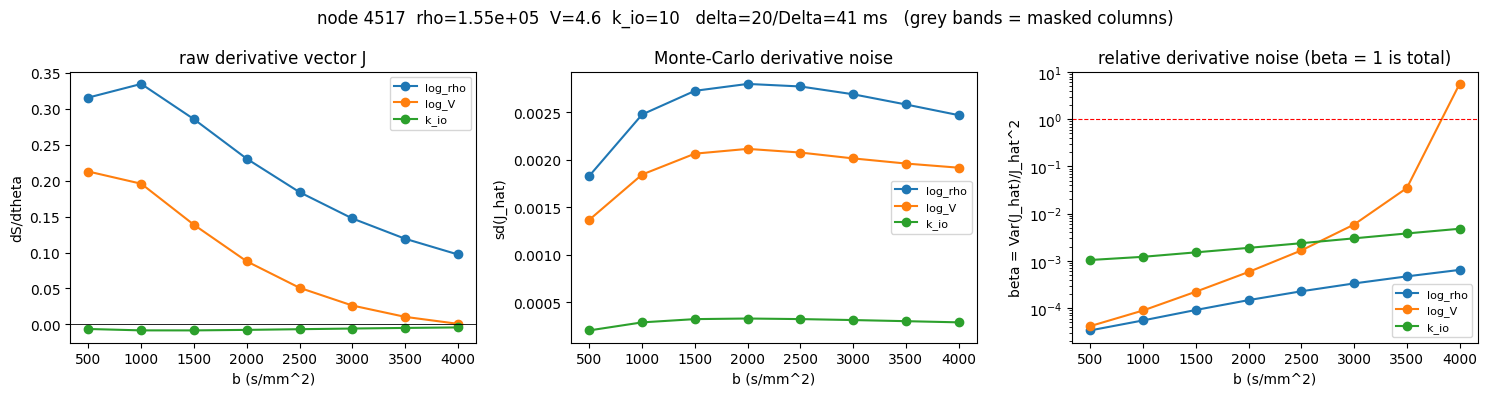

In [16]:
import matplotlib.pyplot as plt

def plot_derivatives(node, pair, size=None, b_values=None):
    """Raw derivative vector, its Monte-Carlo noise, and beta, against b."""
    r = inspect_node(node, pair, b_values=b_values, size=size)
    order = np.argsort(r["b_values"])
    b = r["b_values"][order]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for j, name in enumerate(PARAMETER_ORDER):
        axes[0].plot(b, r["J"][order, j], "o-", label=name)
        axes[1].plot(b, np.sqrt(r["var_J"][order, j]), "o-", label=name)
        axes[2].semilogy(b, r["beta"][order, j], "o-", label=name)
    axes[0].axhline(0, color="k", lw=0.6)
    axes[0].set(xlabel="b (s/mm^2)", ylabel="dS/dtheta", title="raw derivative vector J")
    axes[1].set(xlabel="b (s/mm^2)", ylabel="sd(J_hat)", title="Monte-Carlo derivative noise")
    axes[2].axhline(1.0, color="r", ls="--", lw=0.8)
    axes[2].set(xlabel="b (s/mm^2)", ylabel="beta = Var(J_hat)/J_hat^2",
                title="relative derivative noise (beta = 1 is total)")
    # Mark columns the masks drop.
    dropped = ~r["mask_keep"][order]
    if dropped.any():
        for ax in axes:
            for x in b[dropped]:
                ax.axvline(x, color="0.85", lw=6, zorder=0)
    for ax in axes:
        ax.legend(fontsize=8)
    n = r["node"]
    fig.suptitle(f"node {n['node']}  rho={n['rho_cells_per_uL']:.3g}  V={n['V_pL']:.3g}  "
                 f"k_io={n['k_io_per_s']:.3g}   delta={r['pair']['delta_ms']:.0f}/"
                 f"Delta={r['pair']['Delta_ms']:.0f} ms   (grey bands = masked columns)")
    fig.tight_layout()
    return r

_ = plot_derivatives(NODE, PAIR, size=SUBSET_SIZE)

k_io has no Richardson companion -- pre-registered at k = 1 only -- so it is not plotted.


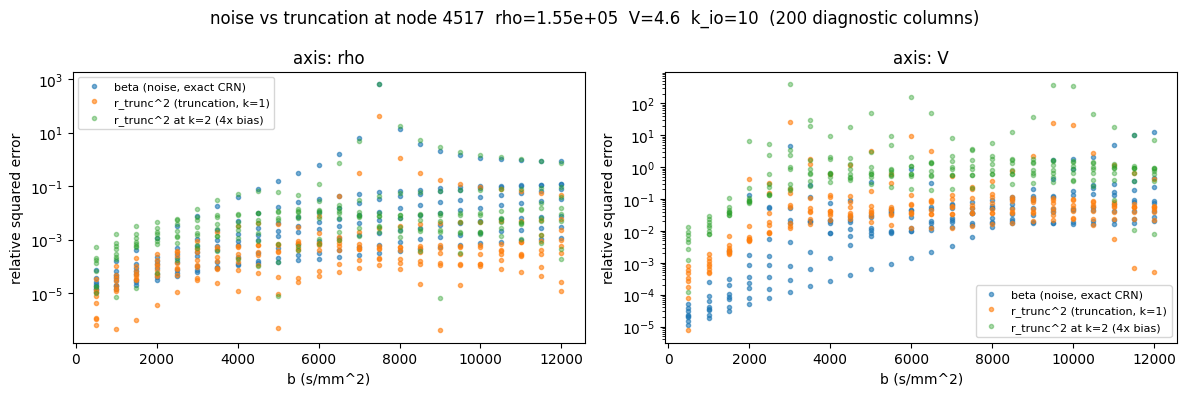

In [17]:
def plot_noise_vs_truncation(node):
    """The trade-off the stencil width choice is about, per axis.

    beta and r_trunc^2 are both relative SQUARED errors on the diagnostic columns,
    so they can be read against each other; total relative squared error at a
    width is approximately beta + r_trunc^2.
    """
    fields = phase1_fields(node)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for axis, ax in zip(("rho", "V"), axes):
        entry = fields[axis]
        b = entry["diagnostic_b_values"]
        beta = entry["beta_exact_diagnostic"]
        r = entry["r_trunc"][DIAGNOSTIC_POSITIONS] if entry["r_trunc"] is not None else None
        order = np.argsort(b)
        ax.semilogy(b[order], beta[order], ".", label="beta (noise, exact CRN)", alpha=0.6)
        if r is not None:
            ax.semilogy(b[order], (r[order]) ** 2, ".", label="r_trunc^2 (truncation, k=1)", alpha=0.6)
            ax.semilogy(b[order], (4.0 * r[order]) ** 2, ".",
                        label="r_trunc^2 at k=2 (4x bias)", alpha=0.4)
        ax.set(xlabel="b (s/mm^2)", ylabel="relative squared error", title=f"axis: {axis}")
        ax.legend(fontsize=8)
    n = node_info(node)
    fig.suptitle(f"noise vs truncation at node {node}  rho={n['rho_cells_per_uL']:.3g}  "
                 f"V={n['V_pL']:.3g}  k_io={n['k_io_per_s']:.3g}  (200 diagnostic columns)")
    fig.tight_layout()
    print("k_io has no Richardson companion -- pre-registered at k = 1 only -- so it is not plotted.")

plot_noise_vs_truncation(NODE)

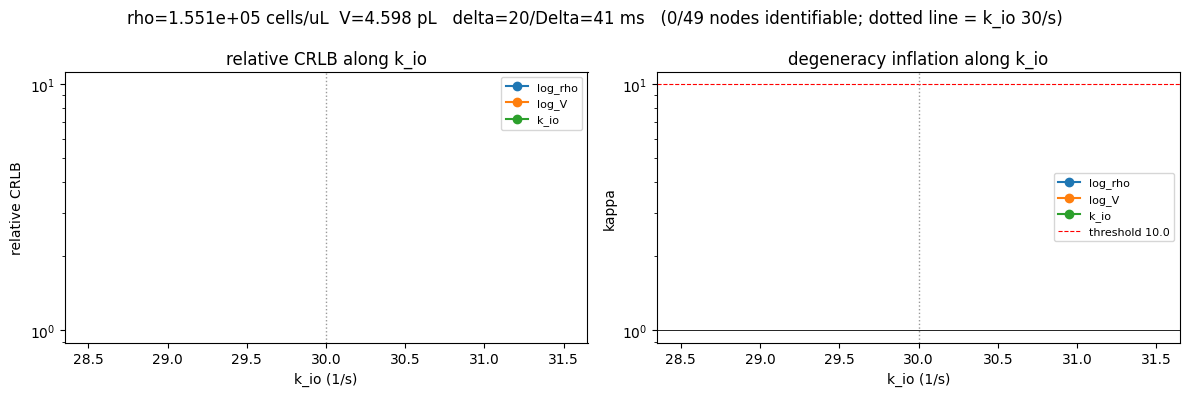

In [18]:
def plot_kio_sweep(rho, V, pair, b_values=None, size=None, n0_eff=None):
    """Relative CRLB and kappa along k_io at one (rho, V), for a fixed acquisition."""
    ir = int(np.argmin(np.abs(RHOS_C - rho)))
    iv = int(np.argmin(np.abs(VS_C - V)))
    nodes = np.flatnonzero((TABLE["nodes"][:, 0] == ir) & (TABLE["nodes"][:, 1] == iv))
    if len(nodes) == 0:
        raise ValueError(f"no nodes at (rho index {ir}, V index {iv}); it is off the mask band")
    rows = [inspect_node(int(n), pair, b_values=b_values, size=size, n0_eff=n0_eff) for n in nodes]
    kio = np.asarray([r["node"]["k_io_per_s"] for r in rows])
    rel = np.asarray([r["relative_crlb"] for r in rows])
    kap = np.asarray([r["kappa"] for r in rows])
    ok = np.asarray([r["identifiable"] for r in rows])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for j, name in enumerate(PARAMETER_ORDER):
        axes[0].semilogy(kio[ok], rel[ok, j], "o-", label=name)
        axes[1].semilogy(kio[ok], kap[ok, j], "o-", label=name)
    axes[0].set(xlabel="k_io (1/s)", ylabel="relative CRLB", title="relative CRLB along k_io")
    axes[1].axhline(KAPPA_THRESHOLD, color="r", ls="--", lw=0.8, label=f"threshold {KAPPA_THRESHOLD}")
    axes[1].axhline(1.0, color="k", lw=0.6)
    axes[1].set(xlabel="k_io (1/s)", ylabel="kappa", title="degeneracy inflation along k_io")
    for ax in axes:
        ax.axvline(30.0, color="0.6", ls=":", lw=1.0)
        ax.legend(fontsize=8)
    fig.suptitle(f"rho={RHOS_C[ir]:.4g} cells/uL  V={VS_C[iv]:.4g} pL   "
                 f"delta={PAIR_DELTAS[pair]:.0f}/Delta={PAIR_BIGDELTA[pair]:.0f} ms   "
                 f"({int(ok.sum())}/{len(nodes)} nodes identifiable; dotted line = k_io 30/s)")
    fig.tight_layout()
    return {"nodes": nodes, "k_io": kio, "relative_crlb": rel, "kappa": kap, "identifiable": ok}

_sweep = plot_kio_sweep(NODE_RHO[NODE], NODE_V[NODE], PAIR, size=SUBSET_SIZE)

In [ ]:
def plot_rho_V_plane(values, k_io_target, title, log=True, ax=None):
    """Scatter a per-node quantity across the (rho, V) plane at one k_io slice."""
    ik = int(np.argmin(np.abs(KIOS_C - float(k_io_target))))
    keep = TABLE["nodes"][:, 2] == ik
    v = np.asarray(values, dtype=float)[keep]
    finite = np.isfinite(v)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    art = ax.scatter(NODE_RHO[keep][finite], NODE_V[keep][finite],
                     c=np.log10(v[finite]) if log else v[finite], s=26, cmap="viridis")
    ax.scatter(NODE_RHO[keep][~finite], NODE_V[keep][~finite], c="crimson", s=26,
               marker="x", label=f"not identifiable ({int((~finite).sum())})")
    ax.set(xscale="log", yscale="log", xlabel="rho (cells/uL)", ylabel="V (pL)",
           title=f"{title}\nk_io = {KIOS_C[ik]:.4g} 1/s")
    plt.colorbar(art, ax=ax, label="log10 value" if log else "value")
    if (~finite).any():
        ax.legend(fontsize=8, loc="lower left")
    return ax


_rel = np.where(BATCH["positive"][:, None], BATCH["relative_crlb"], np.nan)
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for j, name in enumerate(PARAMETER_ORDER):
    plot_rho_V_plane(_rel[:, j], NODE_KIO[NODE], f"relative CRLB, {name}", ax=axes[j])
fig.suptitle(f"single-Delta arm delta={PAIR_DELTAS[_pair]:.0f}/Delta={PAIR_BIGDELTA[_pair]:.0f} ms, "
             f"{SUBSET_SIZE} b-values, N={BUDGET_IMAGES:g}  ({GRADIENT_SCENARIO})")
fig.tight_layout()

In [ ]:
# The maps the Phase-2 run itself wrote, for cross-reading.  Shape (n_nodes, 3),
# aligned with evaluation_node_labels.npy = columns (rho, V, k_io).
def load_phase2_map(scenario, size, arm, regime, quantity):
    """quantity in {'relative_crlb', 'kappa'}; regime in {'known_amplitude', 'n0_eff_4'}."""
    path = PHASE2_DIR / f"maps_{scenario}_size{size}_{arm}.{regime}.{quantity}.npy"
    if not path.exists():
        available = sorted(p.name for p in PHASE2_DIR.glob("maps_*.npy"))
        raise FileNotFoundError(f"{path.name} not written by the run.  Available:\n  " +
                                "\n  ".join(available))
    return np.load(path)

LABELS = np.load(PHASE2_DIR / "evaluation_node_labels.npy")   # (n_nodes, 3): rho, V, k_io
assert np.allclose(LABELS[:, 0], NODE_RHO) and np.allclose(LABELS[:, 2], NODE_KIO), \
    "node ordering differs from this notebook's table -- do not cross-read these maps"

_stored = load_phase2_map(GRADIENT_SCENARIO, SUBSET_SIZE, "m1", "known_amplitude", "relative_crlb")
print("stored map shape:", _stored.shape)
print("agrees with the notebook's batch recomputation:",
      np.allclose(np.nan_to_num(_stored, nan=-1, posinf=-2),
                  np.nan_to_num(BATCH["relative_crlb"].astype(np.float32), nan=-1, posinf=-2),
                  rtol=1e-5, atol=1e-7))

## 8. Things to try

Starting points, not a script. Everything above is a plain function on plain
arrays, so mutate freely.

**Understanding one node**

```python
n = find_node(rho=5e5, V=1.0, k_io=40.0)   # rho in cells/uL, V in pL, k_io in 1/s
show(inspect_node(n, PAIR, size=8), phase1_fields(n))
```

**Why a node is not identifiable.** Look at `F` and `eigenvalues_scaled`: a tiny
smallest eigenvalue with a `(log rho, log V)`-dominated eigenvector is the
volume-fraction degeneracy — `rho` and `V` enter mostly through `v_i = rho*V`.
`kappa` isolates that from the noise level: `kappa_j = 1` means the joint fit
costs nothing on parameter `j`, `kappa_j = 10` means joint estimation inflates
its error tenfold over estimating it alone.

**Where the Monte-Carlo debias decides the verdict**

```python
r = inspect_node(n, PAIR, size=8)
np.linalg.det(r["F"]), np.linalg.det(r["F_undebiased"])   # can flip sign
```

The debias is a 0.03–0.6 % correction to the diagonal that nonetheless flips
identifiability at many nodes, because single-`Delta` Fisher matrices sit very
close to singular. Never read the undebiased number as the answer.

**Sweeping timing**

```python
scores = []
for p in range(len(PAIR_DELTAS)):
    if len(usable_columns(p)) >= 8:
        r = inspect_node(NODE, p, size=8)
        scores.append((PAIR_DELTAS[p], PAIR_BIGDELTA[p], r["relative_crlb"][2], r["identifiable"]))
```

**Amplitude uncertainty.** `inspect_node(..., n0_eff=0)` is the fully unknown-`S0`
bound, `n0_eff=8` is a well-measured reference, `n0_eff=None` is `S0` known
exactly. The gap between `n0_eff=0` and `None` is what amplitude uncertainty
costs — a **variance** statement only. A *biased* amplitude reference (a lowest
shell at `b = 50` rather than `b = 0`) is Phase-4 hypothesis H4 and is **not**
answered by anything in this notebook.

**Both gradient scenarios.** Set `GRADIENT_SCENARIO = "research"` in section 0 and
rerun from section 1. Report the two side by side; the Phase-2 record deliberately
does not nominate one, and pooling them would be meaningless.

**A different b-subset.** `inspect_node(n, PAIR, b_values=[1000, 2000, ...])` takes
an explicit list. The default `size=` path takes the first `size` usable columns in
b order, which is *not* what the Phase-2 run does — it runs a greedy
D-optimal/minimax subset selection per timing pair. To reproduce the run exactly,
pass its chosen list (section 3 prints it), or call
`run_fisher_phase2.greedy_b_subset` yourself.